# NLP Sentiment Analysis Benchmark

A comparative sentiment-analysis project evaluating three approaches:

1. TF-IDF + Logistic Regression
2. PyTorch LSTM with learned word embeddings
3. VADER pretrained sentiment analysis

All approaches are evaluated on the same held-out test set from the NLTK
Movie Reviews dataset using accuracy, Macro F1, Positive-Class F1, training
cost, and inference latency.

## Objective

The objective is to understand the trade-offs between traditional machine
learning, deep learning, and pretrained/lexicon-based sentiment analysis
under a common evaluation framework.

## Key Questions

- Which approach achieves the best predictive performance?
- How much computational cost does each approach require?
- Which approach provides the lowest inference latency?
- How does a pretrained sentiment analyzer perform without domain-specific
  training?
- Which approach provides the best production trade-off between accuracy,
  compute cost, and inference speed?

# 1. Dataset and Preprocessing

## 1. Import Libraries and Set Reproducibility

In [1]:
# ============================================================
# NLP SENTIMENT ANALYSIS BENCHMARK
# Imports + Project Setup
# ============================================================

import sys
import os
import re
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd


# ============================================================
# Project Path
# ============================================================

# Find the project root regardless of whether VS Code starts
# the notebook from the notebooks folder or the project root.

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project 'src' directory.\n"
        f"Current directory: {CURRENT_DIR}"
    )

SRC_DIR = PROJECT_ROOT / "src"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# NLTK
# ============================================================

import nltk

from nltk.corpus import movie_reviews, stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer


# ============================================================
# Machine Learning
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)


# ============================================================
# Deep Learning
# ============================================================

import torch

from torch.utils.data import DataLoader

from src.lstm_model import (
    LSTMClassifier,
    MovieReviewDataset,
    build_vocabulary,
    encode_and_pad,
    train_lstm_with_validation,
    predict_lstm,
)


# ============================================================
# Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# NLTK Resources
# ============================================================

nltk.download("movie_reviews", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("vader_lexicon", quiet=True)


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# Environment Check
# ============================================================

print("=" * 60)
print("PROJECT CHECK")
print("=" * 60)

print("Current directory :", CURRENT_DIR)
print("Project root      :", PROJECT_ROOT)
print("src exists        :", SRC_DIR.exists())
print("results exists    :", RESULTS_DIR.exists())
print("figures exists    :", FIGURES_DIR.exists())

print("\nPython version     :", sys.version.split()[0])
print("PyTorch version    :", torch.__version__)
print(
    "Device             :",
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\n" + "=" * 60)
print("ALL IMPORTS SUCCESSFUL")
print("=" * 60)

PROJECT CHECK
Current directory : C:\Users\Anisha Das\Documents\nlp-sentiment-analysis-benchmark\notebooks
Project root      : C:\Users\Anisha Das\Documents\nlp-sentiment-analysis-benchmark
src exists        : True
results exists    : True
figures exists    : True

Python version     : 3.12.10
PyTorch version    : 2.14.0+cpu
Device             : cpu

ALL IMPORTS SUCCESSFUL


In [2]:
# Reproducibility settings
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed fixed at {SEED}")

Random seed fixed at 42


## 2. Download NLTK Resources

In [3]:
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download("punkt_tab")
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package movie_reviews to C:\Users\Anisha
[nltk_data]     Das\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Anisha
[nltk_data]     Das\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Anisha
[nltk_data]     Das\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Anisha
[nltk_data]     Das\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\Anisha
[nltk_data]     Das\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## 3. Load the NLTK Movie Reviews Dataset

Loading Dataset

In [4]:
documents = []

# Load each review along with its sentiment label
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        review = movie_reviews.raw(fileid)
        documents.append((review, category))

Create a DataFrame

In [5]:
df = pd.DataFrame(documents, columns=['Review', 'Label'])

Preview the Dataset

In [6]:
# Display the first five reviews

df.head()

,Review,Label
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


## 4. Explore the Dataset (Exploratory Data Analysis and Data-Quality Checks)

Display dataset information

In [7]:
print("Total Reviews:", len(df))

print("\nClass Distribution:")
print(df["Label"].value_counts())

print("\nCategories:")
print(movie_reviews.categories())

print("\nDataset Shape:", df.shape)

Total Reviews: 2000

Class Distribution:
Label
neg    1000
pos    1000
Name: count, dtype: int64

Categories:
['neg', 'pos']

Dataset Shape: (2000, 2)


Data Quality Checks

In [8]:
# Check for missing values
print("Missing Values:")
print(df.isna().sum())

# Find every row belonging to a duplicated review
duplicate_mask = df.duplicated(
    subset=["Review"],
    keep=False
)

duplicate_reviews = duplicate_mask.sum()

print("\nNumber of duplicated rows:", duplicate_reviews)

# Check conflicting labels before deleting anything
conflicting_reviews = (
    df.groupby("Review")["Label"]
      .nunique()
      .loc[lambda values: values > 1]
)

print(
    "Number of duplicated reviews with conflicting labels:",
    len(conflicting_reviews)
)

# Display duplicated reviews if they exist
if duplicate_reviews > 0:
    display(
        df.loc[duplicate_mask]
          .sort_values(["Review", "Label"])
    )
else:
    print("No duplicate reviews found.")

Missing Values:
Review    0
Label     0
dtype: int64

Number of duplicated rows: 0
Number of duplicated reviews with conflicting labels: 0
No duplicate reviews found.


In [9]:
# Remove only genuine duplicates with consistent labels
if duplicate_reviews > 0 and len(conflicting_reviews) == 0:
    df = (
        df.drop_duplicates(
            subset=["Review"],
            keep="first"
        )
        .reset_index(drop=True)
    )

    print("Duplicate reviews removed.")
else:
    print("No automatic duplicate removal was performed.")

print("\nFinal dataset shape:", df.shape)
print("\nFinal class distribution:")
print(df["Label"].value_counts())

No automatic duplicate removal was performed.

Final dataset shape: (2000, 2)

Final class distribution:
Label
neg    1000
pos    1000
Name: count, dtype: int64


In [10]:
# Calculate original review lengths
df["Original_Word_Count"] = (
    df["Review"]
    .str.split()
    .str.len()
)

print("Original Review-Length Statistics:")
display(df["Original_Word_Count"].describe())

Original Review-Length Statistics:


count    2000.00000
mean      746.34050
std       328.42529
min        17.00000
25%       526.75000
50%       696.50000
75%       904.00000
max      2678.00000
Name: Original_Word_Count, dtype: float64

Plot Class Distribution

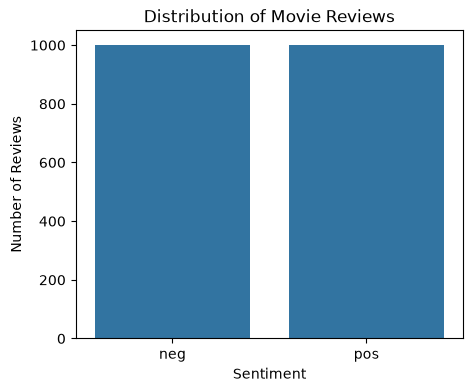

In [11]:
plt.figure(figsize=(5, 4))

sns.countplot(x="Label", data=df)

plt.title("Distribution of Movie Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

## 5. Text Preprocessing

Load English Stopwords

In [12]:
stop_words = set(stopwords.words("english"))

Create the Preprocessing Function

In [13]:
# Preserve sentiment-bearing negation words
sentiment_stop_words = stop_words - {"no", "nor", "not"}

def clean_text(text):
    """
    Cleans a movie review by:
    1. Converting text to lowercase
    2. Normalizing contracted negations
    3. Removing URLs and HTML tags
    4. Removing punctuation, numbers and other noise
    5. Tokenizing the text
    6. Removing non-sentiment stop words
    7. Joining the remaining tokens
    """

    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Normalize contracted negations before removing apostrophes
    text = re.sub(r"n['’]t\b", " not", text)

    # Remove URLs and HTML tags
    text = re.sub(
        r"https?://\S+|www\.\S+|<[^>]+>",
        " ",
        text
    )

    # Retain only alphabetic characters and whitespace
    # This removes punctuation and numbers together
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove excessive whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words while preserving negations
    tokens = [
        token
        for token in tokens
        if token not in sentiment_stop_words and len(token) > 1
    ]

    return " ".join(tokens)

Apply the Function

In [14]:
# Apply preprocessing to every review
df["Clean_Review"] = df["Review"].apply(clean_text)

print("Empty cleaned reviews:", (df["Clean_Review"] == "").sum())

Empty cleaned reviews: 0


Compare Before and After Cleaning

In [15]:
# Compare original and cleaned reviews
df[["Review", "Clean_Review", "Label"]].head()

,Review,Clean_Review,Label
0,"plot : two teen couples go to a church party ,...",plot two teen couples go church party drink dr...,neg
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn bug got ...,neg
2,it is movies like these that make a jaded movi...,movies like make jaded movie viewer thankful i...,neg
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first feature length...,neg
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...,neg


In [16]:
print("Original Review:\n")
print(df.loc[0, "Review"])

print("\nClean Review:\n")
print(df.loc[0, "Clean_Review"])

Original Review:

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience m

## 6. Train-Test Split

Split the Dataset

In [17]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["Label"]
)

train_df = train_df.copy()
test_df = test_df.copy()

# Cleaned text for Logistic Regression and LSTM
X_train = train_df["Clean_Review"]
X_test = test_df["Clean_Review"]

# Original text for VADER
X_test_raw = test_df["Review"]

# Labels shared by all pipelines
y_train = train_df["Label"]
y_test = test_df["Label"]

Verify the Split

In [18]:
print("Training Samples:", len(train_df))
print("Testing Samples:", len(test_df))

print("\nTraining Label Distribution:")
print(y_train.value_counts())

print("\nTesting Label Distribution:")
print(y_test.value_counts())

print("\nClean training shape:", X_train.shape)
print("Clean testing shape:", X_test.shape)
print("Raw VADER testing shape:", X_test_raw.shape)

assert len(X_test) == len(X_test_raw) == len(y_test)
assert X_test.index.equals(X_test_raw.index)
assert X_test.index.equals(y_test.index)

print("\nAll pipelines share the same test-review indices.")

Training Samples: 1600
Testing Samples: 400

Training Label Distribution:
Label
pos    800
neg    800
Name: count, dtype: int64

Testing Label Distribution:
Label
neg    200
pos    200
Name: count, dtype: int64

Clean training shape: (1600,)
Clean testing shape: (400,)
Raw VADER testing shape: (400,)

All pipelines share the same test-review indices.


Summary

- Dataset: NLTK Movie Reviews
- Total Reviews: 2,000
- Positive Reviews: 1,000
- Negative Reviews: 1,000
- Preprocessing applied:
  - Lowercasing
  - Contracted-negation normalization
  - URL and HTML removal
  - Punctuation and number removal
  - Tokenization
  - Stop-word removal while preserving `no`, `nor` and `not`
  - Excess-whitespace removal
- Train-test split: 80:20
- Random seed: 42
- Stratified sampling: Yes
- Shared test set: Same 400 review indices for all pipelines
- Model-specific input:
  - Cleaned reviews for TF-IDF and LSTM
  - Original reviews for VADER

# 2. Traditional ML — TF-IDF + Logistic Regression

## 7. TF-IDF Vectorization

Create the traditional ML pipeline

In [19]:
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Create Logistic Regression classifier
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

Fit the TF-IDF Vectorizer and Logistic Regression Model

In [20]:
# Measure complete pipeline fitting time:
# TF-IDF fitting + Logistic Regression training
training_start_ml = time.perf_counter()

# Learn TF-IDF vocabulary only from training reviews
X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train
)

# Train the classifier
lr_model.fit(
    X_train_tfidf,
    y_train
)

training_time_ml = (
    time.perf_counter() - training_start_ml
)

print(
    f"Complete Training Time: "
    f"{training_time_ml:.4f} seconds"
)

Complete Training Time: 2.9499 seconds


Check training dimensions

In [21]:
print(
    "Training TF-IDF Shape:",
    X_train_tfidf.shape
)

print(
    "Number of TF-IDF Features:",
    len(tfidf_vectorizer.get_feature_names_out())
)

Training TF-IDF Shape: (1600, 5000)
Number of TF-IDF Features: 5000


## 8. Evaluate the Traditional ML Pipeline

Transform and Predict the Test Data

In [22]:
# Measure test transformation and prediction time
inference_start_ml = time.perf_counter()

# Transform test reviews using the training vocabulary
X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)

# Predict test labels
y_pred_ml = lr_model.predict(
    X_test_tfidf
)

inference_time_ml = (
    time.perf_counter() - inference_start_ml
)

inference_per_review_ml = (
    inference_time_ml / len(X_test)
) * 1000

print(
    "Testing TF-IDF Shape:",
    X_test_tfidf.shape
)

print(
    f"Test Inference Time: "
    f"{inference_time_ml:.4f} seconds"
)

print(
    f"Average Inference Time per Review: "
    f"{inference_per_review_ml:.4f} ms"
)

Testing TF-IDF Shape: (400, 5000)
Test Inference Time: 0.3840 seconds
Average Inference Time per Review: 0.9600 ms


Calculate Metrics

Calculate Accuracy

In [23]:
accuracy_ml = accuracy_score(
    y_test,
    y_pred_ml
)

print(f"Accuracy: {accuracy_ml:.4f}")

Accuracy: 0.8475


Calculate Macro F1 Score

In [24]:
f1_ml = f1_score(
    y_test,
    y_pred_ml,
    average="macro"
)

print(f"Macro F1 Score: {f1_ml:.4f}")

Macro F1 Score: 0.8474


Calculate Positive-Class F1 Score

In [25]:
positive_f1_ml = f1_score(
    y_test,
    y_pred_ml,
    pos_label="pos"
)

print(
    f"Positive-Class F1 Score: "
    f"{positive_f1_ml:.4f}"
)

Positive-Class F1 Score: 0.8509


Classification Report

In [26]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_ml,
        labels=["neg", "pos"],
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)


Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      0.82      0.84       200
    Positive       0.83      0.87      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



Confusion Matrix

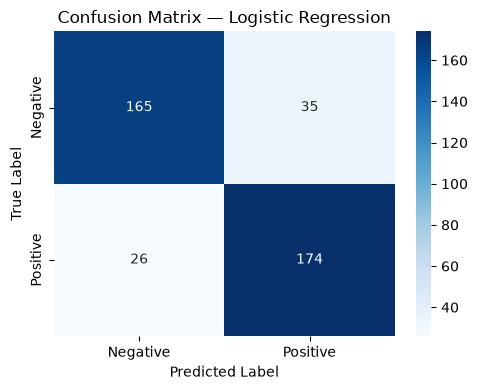

In [27]:
cm_ml = confusion_matrix(
    y_test,
    y_pred_ml,
    labels=["neg", "pos"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_ml,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Display Final Results

In [28]:
print("=" * 55)
print("Traditional Machine Learning Results")
print("=" * 55)

print(f"Accuracy                : {accuracy_ml:.4f}")
print(f"Macro F1 Score          : {f1_ml:.4f}")
print(f"Positive-Class F1       : {positive_f1_ml:.4f}")
print(f"Complete Training Time  : {training_time_ml:.4f} seconds")
print(f"Test Inference Time     : {inference_time_ml:.4f} seconds")
print(f"Inference per Review    : {inference_per_review_ml:.4f} ms")

Traditional Machine Learning Results
Accuracy                : 0.8475
Macro F1 Score          : 0.8474
Positive-Class F1       : 0.8509
Complete Training Time  : 2.9499 seconds
Test Inference Time     : 0.3840 seconds
Inference per Review    : 0.9600 ms


In [29]:
y_test_binary = y_test.map({
    "neg": 0,
    "pos": 1
})

y_prob_ml = lr_model.predict_proba(
    X_test_tfidf
)[:, 1]

roc_auc_ml = roc_auc_score(
    y_test_binary,
    y_prob_ml
)

print(
    f"ROC-AUC: {roc_auc_ml:.4f}"
)

ROC-AUC: 0.9220


Error Analysis

In [30]:
error_analysis = test_df.copy()

error_analysis["Predicted"] = y_pred_ml

error_analysis["Correct"] = (
    error_analysis["Label"] ==
    error_analysis["Predicted"]
)

errors = error_analysis[
    ~error_analysis["Correct"]
].copy()

print(
    "Total test samples:",
    len(error_analysis)
)

print(
    "Misclassified samples:",
    len(errors)
)

print(
    "Error rate:",
    f"{len(errors) / len(error_analysis):.2%}"
)

display(
    errors[
        [
            "Review",
            "Label",
            "Predicted"
        ]
    ].head(20)
)

Total test samples: 400
Misclassified samples: 61
Error rate: 15.25%


,Review,Label,Predicted
466,running time approximately 1hr 40mins \nreview...,neg,pos
106,in the line of duty is the critically praised ...,neg,pos
1028,""" the blair witch project "" was perhaps one o...",pos,neg
1841,"let's face it : since waterworld floated by , ...",pos,neg
563,"the thirteenth floor is a bland , obligatory e...",neg,pos
435,a couple of criminals ( mario van peebles and ...,neg,pos
1201,"whew . this film oozes energy , the kind of br...",pos,neg
427,""" mandingo "" has traditionally been seen as o...",neg,pos
1574,warning ! : may contain some mild spoilers and...,pos,neg
612,joe versus the volcano is really one of the wo...,neg,pos


Uncertainty Analysis

In [31]:
error_analysis["Positive_Probability"] = (
    y_prob_ml
)

error_analysis["Uncertainty"] = (
    np.abs(
        error_analysis["Positive_Probability"]
        - 0.5
    )
)

uncertain_reviews = (
    error_analysis
    .sort_values(
        "Uncertainty"
    )
    .head(20)
)

display(
    uncertain_reviews[
        [
            "Review",
            "Label",
            "Predicted",
            "Positive_Probability"
        ]
    ]
)

,Review,Label,Predicted,Positive_Probability
35,sean connery stars as a harvard law professor ...,neg,pos,0.501512
805,my first exposure to the nightmare on elm stre...,neg,neg,0.498365
34,if you're into watching near on two hours of b...,neg,pos,0.502562
1209,"susan granger's review of "" osmosis jones "" ( ...",pos,pos,0.502962
387,"breakdown is an moderately entertaining , if u...",neg,pos,0.503054
1901,the start of this movie reminded me of parts f...,pos,neg,0.496566
1907,notice : this is a review and analysis of exot...,pos,pos,0.503997
159,synopsis : when a meteorite crashlands in the ...,neg,neg,0.494166
747,"in 1970s , many european intellectuals , espec...",neg,pos,0.506110
646,""" with all that education , you should know w...",neg,pos,0.506489


# 3. Deep Learning — PyTorch LSTM

## 9. Build a Controlled Vocabulary

In [32]:
# ============================================================
# Build Vocabulary from Training Data Only
# ============================================================
preparation_start_lstm = time.perf_counter()

vocab = build_vocabulary(X_train)
PAD_INDEX = vocab["<PAD>"]
UNK_INDEX = vocab["<UNK>"]
print("Vocabulary size:", len(vocab))
print("PAD index:", PAD_INDEX)
print("UNK index:", UNK_INDEX)

# Determine max sequence length (90th percentile, capped at 500)
train_lengths = X_train.str.split().str.len()
MAX_LEN = int(min(500, np.percentile(train_lengths, 90)))
MAX_LEN = max(MAX_LEN, 1)
print("Selected MAX_LEN:", MAX_LEN)

# Encode and pad all reviews
def encode_reviews(reviews):
    return [encode_and_pad(text, vocab, MAX_LEN) for text in reviews]

train_encoded = encode_reviews(X_train)
test_encoded = encode_reviews(X_test)

X_train_pad = [enc[0] for enc in train_encoded]
X_train_lengths = [enc[1] for enc in train_encoded]
X_test_pad = [enc[0] for enc in test_encoded]
X_test_lengths = [enc[1] for enc in test_encoded]

print(f"Training sequences: {len(X_train_pad)}")
print(f"Testing sequences : {len(X_test_pad)}")

# Record preparation time
preparation_time_lstm = time.perf_counter() - preparation_start_lstm
print(f"Preparation time: {preparation_time_lstm:.4f} seconds")

Vocabulary size: 20000
PAD index: 0
UNK index: 1
Selected MAX_LEN: 500
Training sequences: 1600
Testing sequences : 400
Preparation time: 0.3892 seconds


## 10. Define the LSTM Model

In [33]:
# ============================================================
# Create Train / Validation Split for LSTM
# ============================================================

# Convert labels to binary (0/1)
y_train_binary = y_train.map({"neg": 0, "pos": 1}).to_numpy()
y_test_binary = y_test.map({"neg": 0, "pos": 1}).to_numpy()

# Split training data into train / validation (90/10)
X_train_pad, X_val_pad, y_train_bin, y_val_bin, lengths_train, lengths_val = train_test_split(
    X_train_pad,          # padded sequences from the encoding step
    y_train_binary,       # binary labels for training
    X_train_lengths,      # original lengths (without padding)
    test_size=0.10,
    random_state=42,
    stratify=y_train_binary
)

# Create PyTorch datasets
train_dataset = MovieReviewDataset(X_train_pad, lengths_train, y_train_bin)
val_dataset = MovieReviewDataset(X_val_pad, lengths_val, y_val_bin)
test_dataset = MovieReviewDataset(X_test_pad, X_test_lengths, y_test_binary)

# DataLoaders
BATCH_SIZE = 32
generator = torch.Generator().manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 1440
Val samples: 160
Test samples: 400


In [34]:
# ============================================================
# Define LSTM Model
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(
    vocabulary_size=len(vocab),
    padding_index=PAD_INDEX,
    embedding_dimension=100,
    hidden_dimension=128,
    dropout_rate=0.5
).to(device)

## 11. Train the LSTM Model

In [35]:
# ============================================================
# LSTM Training with Validation and Early Stopping
# ============================================================

EPOCHS = 5
PATIENCE = 3
LEARNING_RATE = 0.001

train_start = time.perf_counter()

model, lstm_history = train_lstm_with_validation(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE
)

training_time_lstm = time.perf_counter() - train_start

# Total LSTM preparation + training time
complete_training_time_lstm = (
    preparation_time_lstm + training_time_lstm
)

print(
    f"\nLSTM preparation time: "
    f"{preparation_time_lstm:.4f} seconds"
)

print(
    f"LSTM training time: "
    f"{training_time_lstm:.4f} seconds"
)

print(
    f"LSTM preparation + training time: "
    f"{complete_training_time_lstm:.4f} seconds"
)

Epoch 1/5 - train loss: 0.6944, val loss: 0.6838
Epoch 2/5 - train loss: 0.6658, val loss: 0.6726
Epoch 3/5 - train loss: 0.5937, val loss: 0.6732
Epoch 4/5 - train loss: 0.4911, val loss: 0.7297
Epoch 5/5 - train loss: 0.3777, val loss: 0.7334
Early stopping triggered after 5 epochs.

LSTM preparation time: 0.3892 seconds
LSTM training time: 687.3379 seconds
LSTM preparation + training time: 687.7271 seconds


In [36]:
# ============================================================
# LSTM Test Inference
# ============================================================

inference_start = time.perf_counter()

actual_lstm, predictions_lstm = predict_lstm(
    model=model,
    data_loader=test_loader,
    device=device
)

inference_time_lstm = (
    time.perf_counter() - inference_start
)

inference_per_review_lstm = (
    inference_time_lstm / len(test_dataset)
) * 1000


# ============================================================
# LSTM Metrics
# ============================================================

accuracy_lstm = accuracy_score(
    actual_lstm,
    predictions_lstm
)

f1_lstm = f1_score(
    actual_lstm,
    predictions_lstm,
    average="macro"
)

positive_f1_lstm = f1_score(
    actual_lstm,
    predictions_lstm,
    pos_label=1
)


# ============================================================
# Display Results
# ============================================================

print("=" * 60)
print("LSTM TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy             : "
    f"{accuracy_lstm:.4f}"
)

print(
    f"Macro F1             : "
    f"{f1_lstm:.4f}"
)

print(
    f"Positive-Class F1    : "
    f"{positive_f1_lstm:.4f}"
)

print(
    f"Test inference time  : "
    f"{inference_time_lstm:.4f} seconds"
)

print(
    f"Inference per review : "
    f"{inference_per_review_lstm:.4f} ms"
)

LSTM TEST RESULTS
Accuracy             : 0.5275
Macro F1             : 0.5262
Positive-Class F1    : 0.5013
Test inference time  : 1.7683 seconds
Inference per review : 4.4208 ms


In [37]:
# ============================================================
# LSTM Training History
# ============================================================

history_df = pd.DataFrame({
    "Epoch": range(
        1,
        len(lstm_history["train_loss"]) + 1
    ),
    "Training Loss": lstm_history["train_loss"],
    "Validation Loss": lstm_history["val_loss"]
})

display(history_df)

,Epoch,Training Loss,Validation Loss
0,1,0.694374,0.683793
1,2,0.665795,0.672626
2,3,0.593710,0.673164
3,4,0.491099,0.729739
4,5,0.377709,0.733362


Plot the training loss

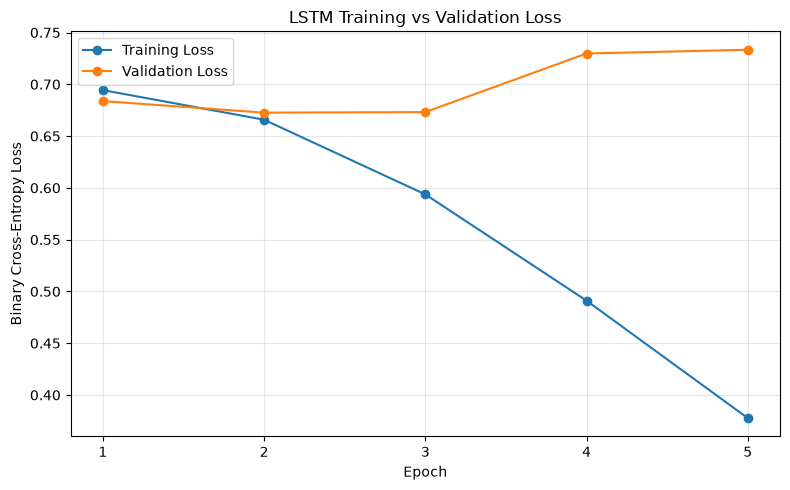

Saved: C:\Users\Anisha Das\Documents\nlp-sentiment-analysis-benchmark\results\figures\lstm_training_validation_loss.png


In [38]:
# ============================================================
# LSTM Training vs Validation Loss
# ============================================================

loss_plot_path = (
    FIGURES_DIR /
    "lstm_training_validation_loss.png"
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Epoch"],
    history_df["Training Loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.xticks(history_df["Epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    loss_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", loss_plot_path)

Interpretation

The training loss should generally decrease as the LSTM learns from the
training data. If validation loss improves initially but subsequently begins
to increase while training loss continues to decrease, the model is showing
signs of overfitting.

The validation curve therefore provides an important diagnostic signal that
cannot be obtained from training loss alone.

For this experiment, the validation loss began increasing after its early
improvement, indicating that additional training was no longer improving
generalization. This supports the use of validation monitoring and early
stopping.

# 4. Pretrained / Lexicon-Based Sentiment — VADER

## 12. Perform VADER Zero-Shot Inference

Predict Sentiment Using VADER

In [39]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

y_pred_vader = []

inference_start_vader = time.perf_counter()

for review in X_test_raw:
    scores = sia.polarity_scores(review)
    compound_score = scores["compound"]

    # Standard VADER sentiment thresholds
    if compound_score >= 0.05:
        prediction = "pos"

    elif compound_score <= -0.05:
        prediction = "neg"

    else:
        # Convert neutral cases into the required binary label
        prediction = (
            "pos"
            if scores["pos"] > scores["neg"]
            else "neg"
        )

    y_pred_vader.append(prediction)

inference_time_vader = (
    time.perf_counter() - inference_start_vader
)

inference_per_review_vader = (
    inference_time_vader / len(X_test_raw)
) * 1000

assert len(y_pred_vader) == len(y_test)
assert set(y_pred_vader).issubset({"neg", "pos"})

print("All VADER predictions completed successfully.")
print(f"Test Inference Time: {inference_time_vader:.4f} seconds")
print(
    f"Average Inference Time per Review: "
    f"{inference_per_review_vader:.4f} ms"
)

All VADER predictions completed successfully.
Test Inference Time: 2.5290 seconds
Average Inference Time per Review: 6.3225 ms


## 13. VADER Model Evaluation

Calculate Metrics

Calculate Accuracy

In [40]:
accuracy_vader = accuracy_score(
    y_test,
    y_pred_vader
)

print(f"Accuracy: {accuracy_vader:.4f}")

Accuracy: 0.6475


Calculate Macro F1 Score

In [41]:
f1_vader = f1_score(
    y_test,
    y_pred_vader,
    average="macro"
)

print(f"Macro F1 Score: {f1_vader:.4f}")

Macro F1 Score: 0.6379


Calculate Positive-Class F1 Score



In [42]:
positive_f1_vader = f1_score(
    y_test,
    y_pred_vader,
    pos_label="pos"
)

print(
    f"Positive-Class F1 Score: "
    f"{positive_f1_vader:.4f}"
)

Positive-Class F1 Score: 0.6968


Classification Report

In [43]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_vader,
        labels=["neg", "pos"],
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)


Classification Report:

              precision    recall  f1-score   support

    Negative       0.72      0.48      0.58       200
    Positive       0.61      0.81      0.70       200

    accuracy                           0.65       400
   macro avg       0.66      0.65      0.64       400
weighted avg       0.66      0.65      0.64       400



Confusion Matrix

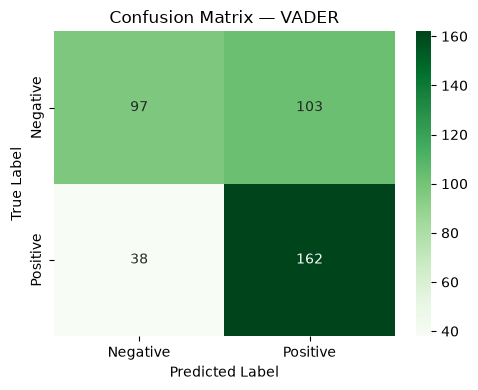

In [44]:
cm_vader = confusion_matrix(
    y_test,
    y_pred_vader,
    labels=["neg", "pos"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_vader,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix — VADER")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Display Final Results

In [45]:
print("=" * 55)
print("Off-the-Shelf VADER Results")
print("=" * 55)

print(f"Accuracy                : {accuracy_vader:.4f}")
print(f"Macro F1 Score          : {f1_vader:.4f}")
print(f"Positive-Class F1       : {positive_f1_vader:.4f}")
print(f"Training Time           : 0.0000 seconds")
print(f"Test Inference Time     : {inference_time_vader:.4f} seconds")
print(f"Inference per Review    : {inference_per_review_vader:.4f} ms")

Off-the-Shelf VADER Results
Accuracy                : 0.6475
Macro F1 Score          : 0.6379
Positive-Class F1       : 0.6968
Training Time           : 0.0000 seconds
Test Inference Time     : 2.5290 seconds
Inference per Review    : 6.3225 ms


# 5. Cross-Model Benchmark

Create Comparison Table

In [46]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LSTM",
        "VADER"
    ],

    "Accuracy": [
        accuracy_ml,
        accuracy_lstm,
        accuracy_vader
    ],

    "Macro F1": [
        f1_ml,
        f1_lstm,
        f1_vader
    ],

    "Positive-Class F1": [
        positive_f1_ml,
        positive_f1_lstm,
        positive_f1_vader
    ],

    "Preparation + Training Time (seconds)": [
        training_time_ml,
        complete_training_time_lstm,
        0.0
    ],

    "Test Inference Time (seconds)": [
        inference_time_ml,
        inference_time_lstm,
        inference_time_vader
    ],

    "Inference per Review (ms)": [
        inference_per_review_ml,
        inference_per_review_lstm,
        inference_per_review_vader
    ]
})

comparison_df.round(4)

,Model,Accuracy,Macro F1,Positive-Class F1,Preparation + Training Time (seconds),Test Inference Time (seconds),Inference per Review (ms)
0,Logistic Regression,0.8475,0.8474,0.8509,2.9499,0.3840,0.9600
1,LSTM,0.5275,0.5262,0.5013,687.7271,1.7683,4.4208
2,VADER,0.6475,0.6379,0.6968,0.0000,2.5290,6.3225


Find the best-performing models automatically

In [47]:
best_accuracy_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(),
    "Model"
]

best_f1_model = comparison_df.loc[
    comparison_df["Macro F1"].idxmax(),
    "Model"
]

fastest_inference_model = comparison_df.loc[
    comparison_df[
        "Test Inference Time (seconds)"
    ].idxmin(),
    "Model"
]

print("Highest Accuracy:", best_accuracy_model)
print("Highest Macro F1:", best_f1_model)
print("Fastest Test Inference:", fastest_inference_model)
print("No-Training Model: VADER")

Highest Accuracy: Logistic Regression
Highest Macro F1: Logistic Regression
Fastest Test Inference: Logistic Regression
No-Training Model: VADER


Accuracy Comparison Chart

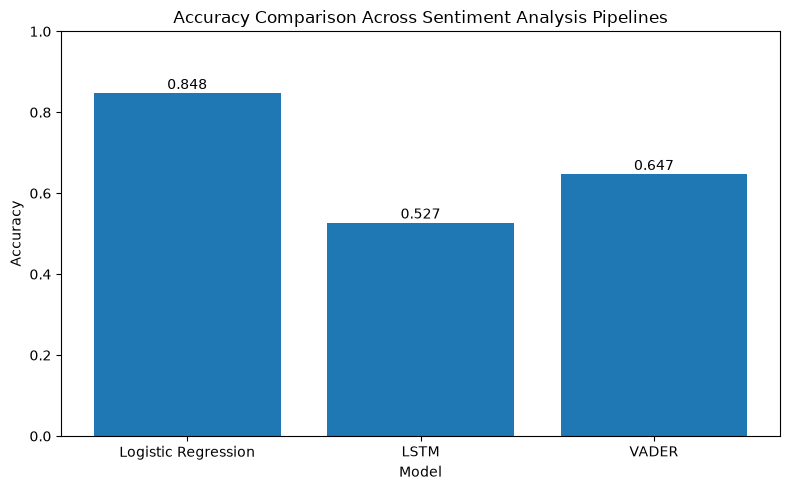

In [48]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison Across Sentiment Analysis Pipelines")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Display values above the bars
for bar, value in zip(bars, comparison_df["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Macro F1 Score comparison chart

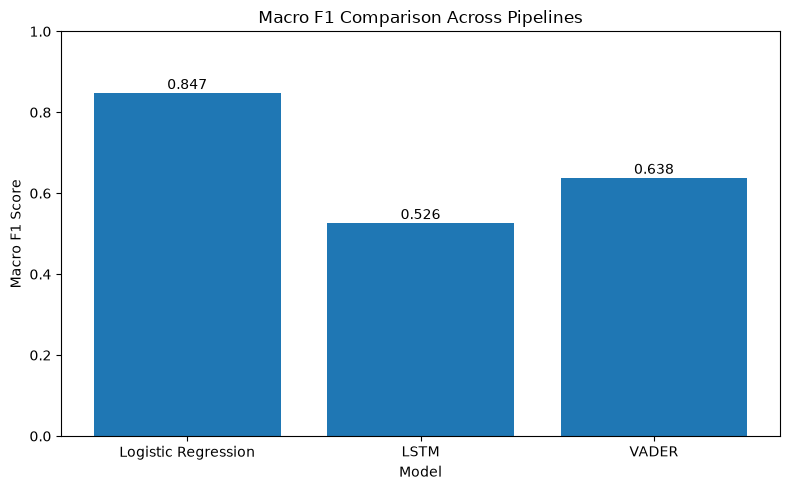

In [49]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Macro F1"]
)

plt.title("Macro F1 Comparison Across Pipelines")
plt.xlabel("Model")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1)

for bar, value in zip(
    bars,
    comparison_df["Macro F1"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Time Comparison Chart - Preparation and training time

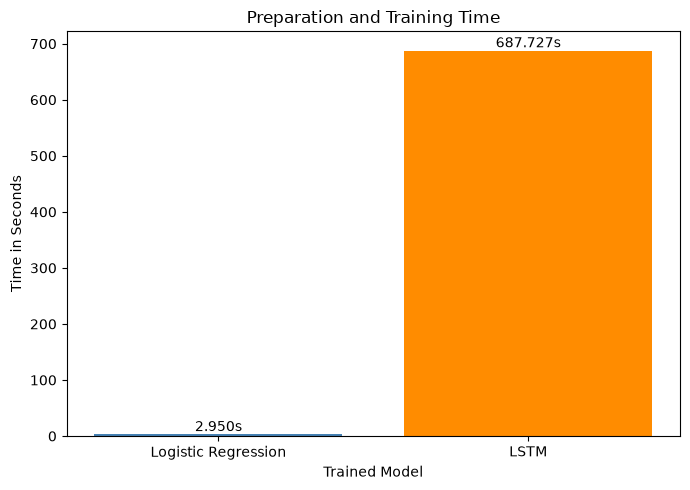

In [50]:
trained_models_df = comparison_df[
    comparison_df["Model"] != "VADER"
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    trained_models_df["Model"],
    trained_models_df[
        "Preparation + Training Time (seconds)"
    ],
    color=["steelblue", "darkorange"]
)

plt.title("Preparation and Training Time")
plt.xlabel("Trained Model")
plt.ylabel("Time in Seconds")

for bar, value in zip(
    bars,
    trained_models_df[
        "Preparation + Training Time (seconds)"
    ]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

> **Note:** VADER is excluded from the training-time chart because it was used as an off-the-shelf model and required no training.

Test inference time

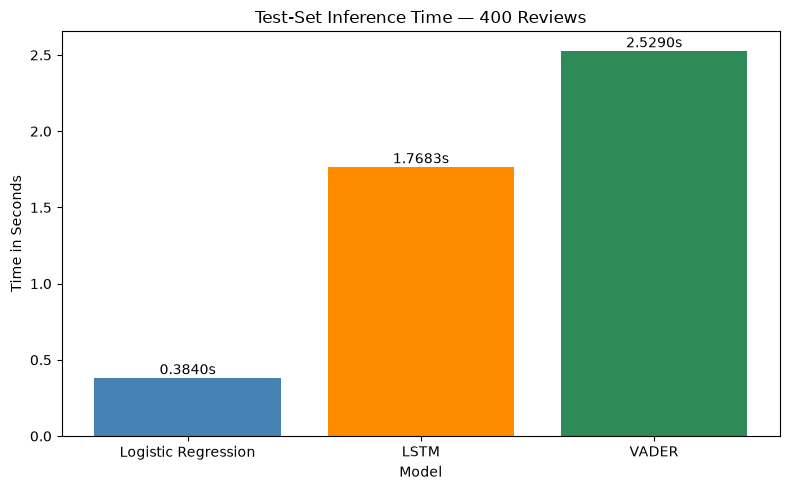

In [51]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Test Inference Time (seconds)"],
    color=["steelblue", "darkorange", "seagreen"]
)

plt.title("Test-Set Inference Time — 400 Reviews")
plt.xlabel("Model")
plt.ylabel("Time in Seconds")

for bar, value in zip(
    bars,
    comparison_df["Test Inference Time (seconds)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Combined Accuracy and F1 chart

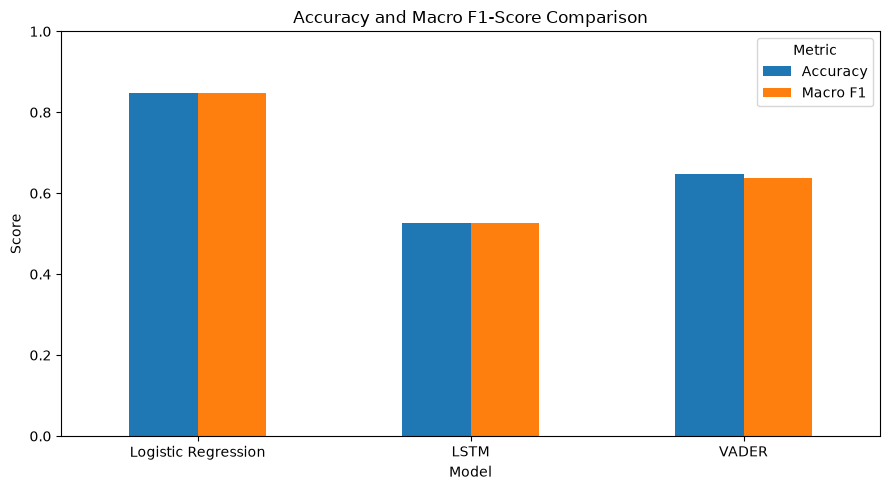

In [52]:
metrics_df = comparison_df.set_index("Model")[
    ["Accuracy", "Macro F1"]
]

metrics_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Accuracy and Macro F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

Final Metric Values for Reporting

In [53]:
print(
    f"Logistic Regression: Accuracy={accuracy_ml:.4f}, "
    f"Macro F1={f1_ml:.4f}, "
    f"Training={training_time_ml:.4f}s, "
    f"Inference={inference_time_ml:.4f}s"
)

print(
    f"LSTM: Accuracy={accuracy_lstm:.4f}, "
    f"Macro F1={f1_lstm:.4f}, "
    f"Preparation+Training="
    f"{complete_training_time_lstm:.4f}s, "
    f"Inference={inference_time_lstm:.4f}s"
)

print(
    f"VADER: Accuracy={accuracy_vader:.4f}, "
    f"Macro F1={f1_vader:.4f}, "
    f"Training=0.0000s, "
    f"Inference={inference_time_vader:.4f}s"
)

Logistic Regression: Accuracy=0.8475, Macro F1=0.8474, Training=2.9499s, Inference=0.3840s
LSTM: Accuracy=0.5275, Macro F1=0.5262, Preparation+Training=687.7271s, Inference=1.7683s
VADER: Accuracy=0.6475, Macro F1=0.6379, Training=0.0000s, Inference=2.5290s


Quantitative Comparison

In [54]:
comparison_analysis = comparison_df.copy()

best_accuracy = (
    comparison_analysis["Accuracy"].max()
)

best_macro_f1 = (
    comparison_analysis["Macro F1"].max()
)

comparison_analysis[
    "Accuracy Gap vs Best (percentage points)"
] = (
    (
        best_accuracy -
        comparison_analysis["Accuracy"]
    ) * 100
).round(2)

comparison_analysis[
    "Macro F1 Gap vs Best (percentage points)"
] = (
    (
        best_macro_f1 -
        comparison_analysis["Macro F1"]
    ) * 100
).round(2)

display(
    comparison_analysis
)

,Model,Accuracy,Macro F1,Positive-Class F1,Preparation + Training Time (seconds),Test Inference Time (seconds),Inference per Review (ms),Accuracy Gap vs Best (percentage points),Macro F1 Gap vs Best (percentage points)
0,Logistic Regression,0.8475,0.847423,0.850856,2.949880,0.383993,0.959983,0.0,0.00
1,LSTM,0.5275,0.526194,0.501319,687.727104,1.768337,4.420842,32.0,32.12
2,VADER,0.6475,0.637939,0.696774,0.000000,2.529002,6.322505,20.0,20.95


Production Efficiency Analysis

In [55]:
lr_training_time = comparison_df.loc[
    comparison_df["Model"] == "Logistic Regression",
    "Preparation + Training Time (seconds)"
].iloc[0]

lstm_training_time = comparison_df.loc[
    comparison_df["Model"] == "LSTM",
    "Preparation + Training Time (seconds)"
].iloc[0]

print(
    "LSTM / Logistic Regression "
    f"training-time ratio: "
    f"{lstm_training_time / lr_training_time:.2f}x"
)

LSTM / Logistic Regression training-time ratio: 233.14x


Figures will be saved to:
C:\Users\Anisha Das\Documents\nlp-sentiment-analysis-benchmark\results\figures


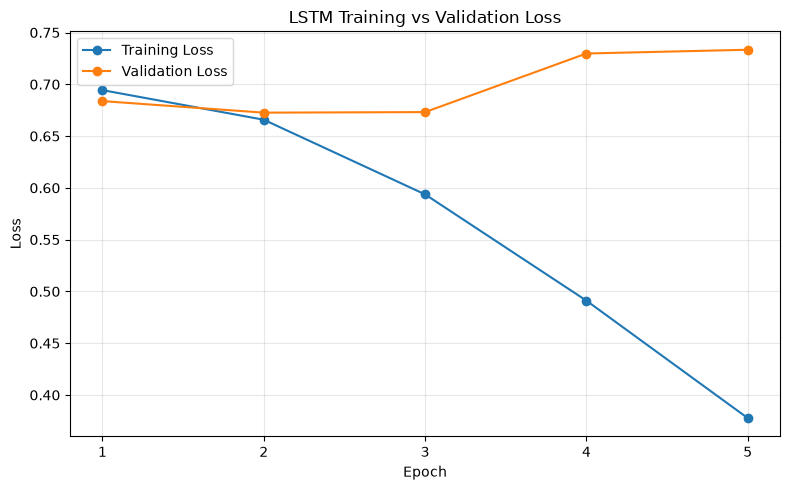

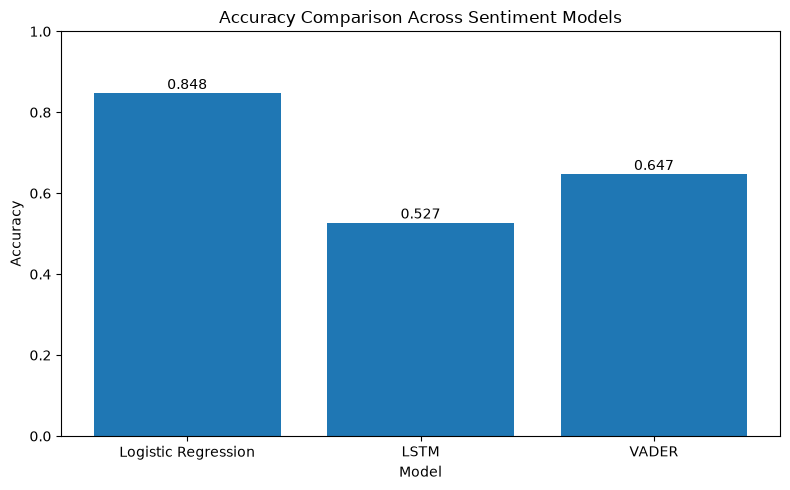

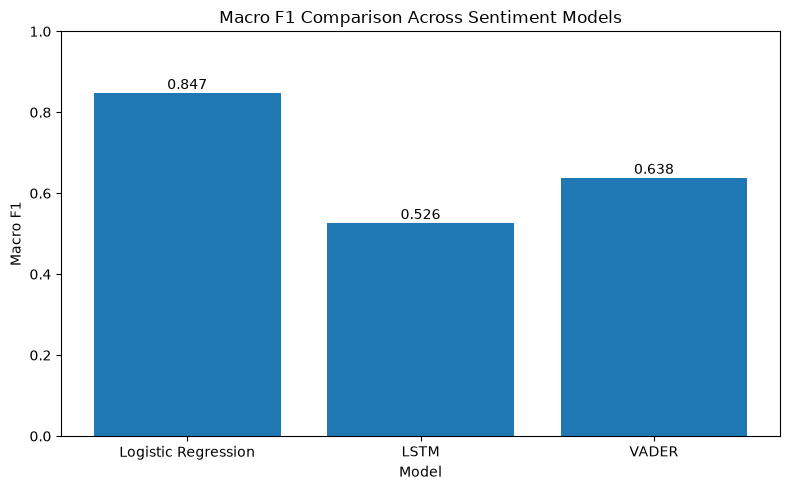

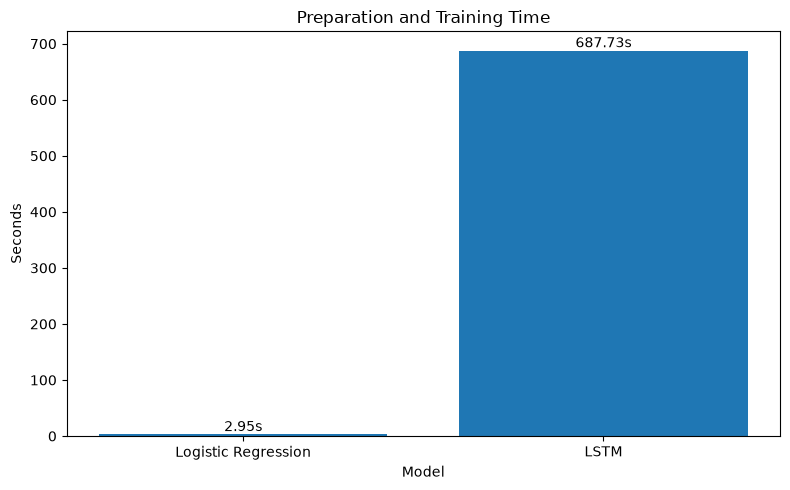

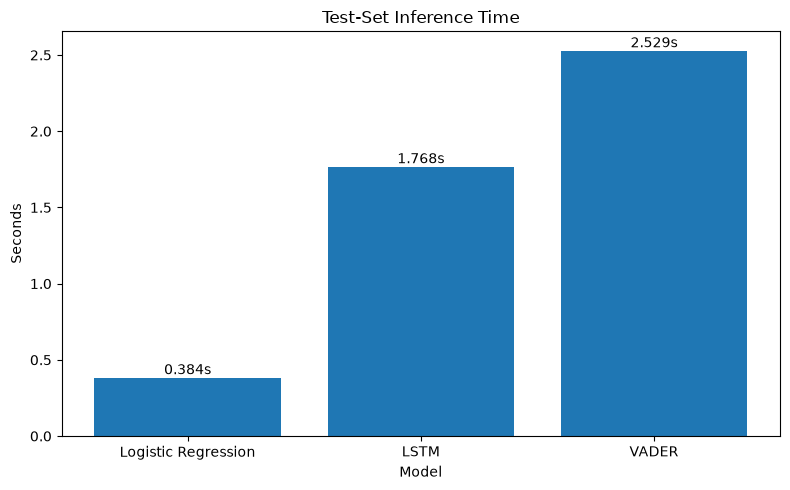


All figures saved successfully:
 - accuracy_comparison.png
 - f1_comparison.png
 - inference_latency.png
 - lstm_training_validation_loss.png
 - training_time_comparison.png


In [56]:
# ============================================================
# SAVE BENCHMARK FIGURES
# ============================================================

# Project root = parent of the notebooks folder
PROJECT_ROOT = Path.cwd().resolve().parent

# Existing results/figures directory
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

# Create it only if it does not already exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:")
print(FIGURES_DIR)


# ============================================================
# 1. LSTM Training vs Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Epoch"],
    history_df["Training Loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.xticks(history_df["Epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "lstm_training_validation_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. Accuracy Comparison
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison Across Sentiment Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar, value in zip(
    bars,
    comparison_df["Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "accuracy_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. Macro F1 Comparison
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Macro F1"]
)

plt.title("Macro F1 Comparison Across Sentiment Models")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)

for bar, value in zip(
    bars,
    comparison_df["Macro F1"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "f1_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. Training Time Comparison
# ============================================================

trained_models = comparison_df[
    comparison_df["Model"] != "VADER"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    trained_models["Model"],
    trained_models["Preparation + Training Time (seconds)"]
)

plt.title("Preparation and Training Time")
plt.xlabel("Model")
plt.ylabel("Seconds")

for bar, value in zip(
    bars,
    trained_models["Preparation + Training Time (seconds)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "training_time_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. Test-Set Inference Time
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Test Inference Time (seconds)"]
)

plt.title("Test-Set Inference Time")
plt.xlabel("Model")
plt.ylabel("Seconds")

for bar, value in zip(
    bars,
    comparison_df["Test Inference Time (seconds)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "inference_latency.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Final Check
# ============================================================

print("\nAll figures saved successfully:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", file.name)

# 6. Error Analysis and Model Insights

The benchmark shows that TF-IDF + Logistic Regression is the strongest model
overall. Aggregate metrics, however, do not reveal which types of reviews are
difficult to classify.

This section examines misclassified reviews, prediction confidence,
performance gaps, computational cost, and the reasons why the three
approaches behaved differently.

**6.1 Logistic Regression Error Analysis**

The Logistic Regression model achieved the highest Accuracy and Macro F1.
The following analysis identifies the test reviews that it classified
incorrectly.

In [57]:
# Create an error-analysis DataFrame for Logistic Regression

error_analysis = test_df.copy()

error_analysis["Predicted"] = y_pred_ml

error_analysis["Correct"] = (
    error_analysis["Label"]
    == error_analysis["Predicted"]
)

errors_ml = error_analysis[
    ~error_analysis["Correct"]
].copy()

print("Total test reviews:", len(error_analysis))
print("Misclassified reviews:", len(errors_ml))
print(
    "Error rate:",
    f"{len(errors_ml) / len(error_analysis):.2%}"
)

display(
    errors_ml[
        [
            "Review",
            "Label",
            "Predicted"
        ]
    ].head(20)
)

Total test reviews: 400
Misclassified reviews: 61
Error rate: 15.25%


,Review,Label,Predicted
466,running time approximately 1hr 40mins \nreview...,neg,pos
106,in the line of duty is the critically praised ...,neg,pos
1028,""" the blair witch project "" was perhaps one o...",pos,neg
1841,"let's face it : since waterworld floated by , ...",pos,neg
563,"the thirteenth floor is a bland , obligatory e...",neg,pos
435,a couple of criminals ( mario van peebles and ...,neg,pos
1201,"whew . this film oozes energy , the kind of br...",pos,neg
427,""" mandingo "" has traditionally been seen as o...",neg,pos
1574,warning ! : may contain some mild spoilers and...,pos,neg
612,joe versus the volcano is really one of the wo...,neg,pos


**6.2 Error Distribution by True Sentiment**

Examining the true labels of misclassified reviews helps determine whether
errors are concentrated more heavily in one sentiment class.

In [58]:
error_distribution = (
    errors_ml["Label"]
    .value_counts()
    .rename_axis("True Label")
    .reset_index(name="Misclassified Reviews")
)

display(error_distribution)

,True Label,Misclassified Reviews
0,neg,35
1,pos,26


The distribution of errors provides additional context beyond overall
Accuracy. A balanced test set does not guarantee that the model makes the same
number of errors for positive and negative reviews.

**6.3 Prediction Confidence Analysis**

Logistic Regression produces class probabilities. These probabilities can be
used to identify predictions that are close to the decision boundary and are
therefore relatively uncertain.

In [59]:
# Obtain positive-class probabilities
y_prob_ml = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Add probabilities to the full test analysis DataFrame
error_analysis["Positive_Probability"] = y_prob_ml
error_analysis["Uncertainty"] = abs(error_analysis["Positive_Probability"] - 0.5)

# Recompute errors subset AFTER adding the new column
errors_ml = error_analysis[~error_analysis["Correct"]].copy()

# Show the most uncertain reviews (closest to 0.5)
uncertain_reviews = error_analysis.sort_values("Uncertainty").head(20)
display(uncertain_reviews[["Review", "Label", "Predicted", "Positive_Probability"]])

,Review,Label,Predicted,Positive_Probability
35,sean connery stars as a harvard law professor ...,neg,pos,0.501512
805,my first exposure to the nightmare on elm stre...,neg,neg,0.498365
34,if you're into watching near on two hours of b...,neg,pos,0.502562
1209,"susan granger's review of "" osmosis jones "" ( ...",pos,pos,0.502962
387,"breakdown is an moderately entertaining , if u...",neg,pos,0.503054
1901,the start of this movie reminded me of parts f...,pos,neg,0.496566
1907,notice : this is a review and analysis of exot...,pos,pos,0.503997
159,synopsis : when a meteorite crashlands in the ...,neg,neg,0.494166
747,"in 1970s , many european intellectuals , espec...",neg,pos,0.506110
646,""" with all that education , you should know w...",neg,pos,0.506489


**6.4 Confidently Misclassified Reviews**

Some errors are more informative than others. A review that is classified
incorrectly with high confidence is particularly useful for understanding the
limitations of a model.

In [60]:
confident_errors = (
    errors_ml
    .assign(Confidence=lambda df: abs(df["Positive_Probability"] - 0.5))
    .sort_values("Confidence", ascending=False)
)

display(confident_errors[["Review", "Label", "Predicted", "Positive_Probability"]].head(10))

,Review,Label,Predicted,Positive_Probability
475,"miramax "" disinvited "" on-line media from pres...",neg,pos,0.734900
1603,"in october of 1997 , audiences were dazzled by...",pos,neg,0.273214
1282,"ok , let's get one thing straight right away :...",pos,neg,0.318919
700,""" the beach "" is a structurally confusing fil...",neg,pos,0.671126
1876,usually when one is debating who the modern qu...,pos,neg,0.342655
1028,""" the blair witch project "" was perhaps one o...",pos,neg,0.357229
838,"in our time . \nin our modern world , where th...",neg,pos,0.635513
466,running time approximately 1hr 40mins \nreview...,neg,pos,0.631441
600,silly performances and some huge gaps in logic...,neg,pos,0.629240
379,"in my review of "" the spy who shagged me , "" i...",neg,pos,0.627675


**6.5 Quantified Performance Differences**

The measured results show a substantial gap between the three pipelines.

In [61]:
lr_accuracy = comparison_df.loc[
    comparison_df["Model"] == "Logistic Regression",
    "Accuracy"
].iloc[0]

lstm_accuracy = comparison_df.loc[
    comparison_df["Model"] == "LSTM",
    "Accuracy"
].iloc[0]

vader_accuracy = comparison_df.loc[
    comparison_df["Model"] == "VADER",
    "Accuracy"
].iloc[0]

lr_f1 = comparison_df.loc[
    comparison_df["Model"] == "Logistic Regression",
    "Macro F1"
].iloc[0]

lstm_f1 = comparison_df.loc[
    comparison_df["Model"] == "LSTM",
    "Macro F1"
].iloc[0]

vader_f1 = comparison_df.loc[
    comparison_df["Model"] == "VADER",
    "Macro F1"
].iloc[0]

print(
    f"Logistic Regression vs LSTM Accuracy gap: "
    f"{(lr_accuracy - lstm_accuracy) * 100:.2f} percentage points"
)

print(
    f"Logistic Regression vs VADER Accuracy gap: "
    f"{(lr_accuracy - vader_accuracy) * 100:.2f} percentage points"
)

print(
    f"Logistic Regression vs LSTM Macro F1 gap: "
    f"{(lr_f1 - lstm_f1) * 100:.2f} percentage points"
)

print(
    f"Logistic Regression vs VADER Macro F1 gap: "
    f"{(lr_f1 - vader_f1) * 100:.2f} percentage points"
)

Logistic Regression vs LSTM Accuracy gap: 32.00 percentage points
Logistic Regression vs VADER Accuracy gap: 20.00 percentage points
Logistic Regression vs LSTM Macro F1 gap: 32.12 percentage points
Logistic Regression vs VADER Macro F1 gap: 20.95 percentage points


**6.6 Computational Cost**

The difference in computational cost is substantial.

In the latest benchmark, TF-IDF + Logistic Regression required approximately **2.95 seconds** for preparation and training, while the LSTM required approximately **687.73 seconds**.

This corresponds to roughly a **233× difference** in preparation and training time.

The result highlights an important ML engineering principle: model complexity should be justified by measurable performance improvements rather than treated as an automatic indicator of model quality.

The measured times are environment-dependent and should therefore be interpreted as benchmark measurements from this experiment rather than universal runtime guarantees.


**6.7 Why Did Logistic Regression Perform Best?**

TF-IDF + Logistic Regression achieved the strongest results in this
experiment.

One plausible explanation is that movie-review sentiment contains many
highly informative lexical patterns. TF-IDF represents the importance of
individual words and word pairs, allowing the linear classifier to learn
strong associations between lexical features and sentiment.

The dataset contains only 2,000 labelled reviews, with 1,600 used for
training. This is a relatively small dataset for training a sequence model
from scratch. The LSTM therefore has less labelled data from which to learn
useful representations and contextual patterns.

These are experimental interpretations rather than proven causal
explanations. Larger datasets, pretrained embeddings, and more extensive
LSTM tuning would be required to determine how much each factor contributes
to the observed performance gap.

**6.8 VADER and Domain Adaptation**

VADER generated predictions without being trained on the Movie Reviews
training set. Instead, it relies on a predefined sentiment lexicon and
rule-based scoring.

This provides an important advantage: VADER can be used when labelled
training data is unavailable and has essentially no dataset-specific model
training cost.

However, the target dataset consists of long movie reviews rather than the
short, expressive text patterns for which rule-based sentiment analysis is
particularly useful. Movie reviews can contain sarcasm, mixed opinions,
contrastive statements, narrative descriptions, and sentiment that depends on
context across multiple sentences.

By contrast, Logistic Regression and the LSTM were trained directly on the
movie-review training data.

VADER was therefore useful as a training-free baseline, but its predefined
sentiment knowledge was less adapted to the target domain than the
supervised approaches.

**6.9 Selection of Evaluation Metrics**

Accuracy was selected because the Movie Reviews dataset is balanced, with
1,000 positive and 1,000 negative reviews. Therefore, accuracy provides a
clear measure of overall classification correctness.

Macro F1 was selected as the primary complementary metric because it gives
equal importance to the positive and negative classes. This helps identify
whether performance is strong across both sentiment classes rather than
being dominated by one class.

Positive-class F1 was reported as a supplementary metric to examine
performance specifically for positive sentiment.

Classification reports and confusion matrices were also used to provide
class-level diagnostic information.

# 7. Production Recommendation

## 7.1 Recommended Model

For the current dataset and target use case, **TF-IDF + Logistic Regression is the recommended initial production model**.

It achieved:

* Accuracy: **84.75%**
* Macro F1: **84.74%**
* Positive-Class F1: **85.09%**
* Preparation + training time: **approximately 2.95 seconds**
* Test-set inference time: **approximately 0.38 seconds**

It therefore provides the strongest combination of predictive performance, computational efficiency, implementation simplicity and maintainability in this experiment.

## 7.2 Comparison of Production Trade-offs

| Factor                      | Logistic Regression         | LSTM                        | VADER                  |
| --------------------------- | --------------------------- | --------------------------- | ---------------------- |
| Accuracy                    | **84.75%**                  | 52.75%                      | 64.75%                 |
| Macro F1                    | **84.74%**                  | 52.62%                      | 63.79%                 |
| Positive-Class F1           | **85.09%**                  | 50.13%                      | 69.68%                 |
| Training Required           | Yes                         | Yes                         | **No**                 |
| Preparation + Training Cost | **Low**                     | High                        | **None**               |
| Test Inference Time         | **0.384 s**                 | 1.768 s                     | 2.529 s                |
| Inference per Review        | **0.960 ms**                | 4.421 ms                    | 6.323 ms               |
| Model Complexity            | **Low**                     | High                        | Low                    |
| Domain Adaptation           | **Learns from target data** | **Learns from target data** | General-purpose        |
| Current Recommendation      | **Primary model**           | Future candidate            | Training-free baseline |

## 7.3 When VADER Is Appropriate

VADER remains useful when labelled training data is unavailable or when a
training-free baseline is required.

Its main advantage is that it can be deployed without fitting a
dataset-specific classifier.

However, the current experiment indicates that this convenience comes with a
substantial reduction in predictive performance.

## 7.4 When LSTM Is Appropriate

The LSTM becomes more attractive when substantially more labelled training
data, additional computational resources, or sequence-level modelling
requirements are available.

The current experiment does not justify the additional complexity because the
LSTM achieved considerably lower performance while requiring much more
preparation and training time.

## 7.5 Recommended Deployment Strategy

The recommended initial strategy is:

**TF-IDF → Logistic Regression → sentiment prediction**

VADER can be retained as a lightweight baseline or fallback when training
data is unavailable.

The LSTM should be retained as an experimental candidate for future work,
particularly after increasing the training-data volume and evaluating
pretrained embeddings or transformer-based approaches.

After deployment, performance should be monitored over time because the
language and characteristics of incoming reviews may change. Newly labelled
reviews can then be used for periodic retraining and model evaluation.

# 8. Conclusion

This project benchmarked three sentiment-analysis approaches on the same NLTK Movie Reviews test partition: TF-IDF + Logistic Regression, a PyTorch LSTM trained with learned word embeddings, and the pretrained VADER sentiment analyzer.

The measured results clearly favoured **TF-IDF + Logistic Regression**, which achieved **84.75% Accuracy, 84.74% Macro F1 and 85.09% Positive-Class F1**. It also required approximately **2.95 seconds** for preparation and training and **0.38 seconds** for inference on the 400-review test set.

The LSTM achieved **52.75% Accuracy, 52.62% Macro F1 and 50.13% Positive-Class F1**, while requiring approximately **687.73 seconds** for preparation and training. Therefore, the more complex sequence model did not provide a performance advantage on this relatively small dataset.

VADER achieved **64.75% Accuracy, 63.79% Macro F1 and 69.68% Positive-Class F1** without dataset-specific training. Its main strength is its training-free nature, but its general-purpose sentiment rules were less effective than the supervised Logistic Regression approach for this movie-review domain.

Error analysis further shows that aggregate metrics alone are not sufficient to understand model behaviour. Inspecting misclassified and low-confidence reviews provides insight into difficult cases involving mixed sentiment, negation, sarcasm and contextual language.

From a production perspective, the experiment supports selecting **TF-IDF + Logistic Regression as the initial deployment model** because it offers the strongest balance of predictive quality, computational efficiency, simplicity and maintainability.

The broader lesson is that model selection should not be based solely on architectural complexity. A practical NLP system should consider predictive quality, training data, computation, inference latency, domain suitability, interpretability and maintenance requirements together.

Future work can extend this benchmark with larger datasets, pretrained embeddings, transformer-based models, systematic hyperparameter optimization, model serving and production monitoring.
